<img align="right" width="400" src="https://drive.google.com/thumbnail?id=1rPeHEqFWHJcauZlU82a4hXM10TUjmHxM&sz=s4000" alt="FHNW Logo">


# Structured Information Extraction with a LLM

by Fabian Märki

## Summary
The aim of this notebook is to showcase (structured) Information Extraction by instructing a LLM to extract information in a structured format. 

LLMs produce free text by default. Assuming that the LLM should become part of a software stack (e.g. as a microservice), this faces us with the problem on how to process this text (as other services in the pipeline expect structured input and cannot handle free text). Luckily, there are ways to instruct an LLM to respond in a predefined JSON format (or in a Pydantic class using LangChain's oecosystem).

This notebook contains assigments: <font color='red'>Questions are written in red.</font>

<a href="https://colab.research.google.com/github/markif/NLP_LAB_CAS/blob/master/Structured_Information_Extraction_with_a_LLM.ipynb">
  <img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
%%capture

!pip install 'fhnw-nlp-utils>=0.11.0,<0.12.0'

In [2]:
from fhnw.nlp.utils.storage import download
from fhnw.nlp.utils.image_helpers import image_to_base64

In [3]:
file_llama = "data/llama_waving.png"
file_stop_sign = "data/stop_sign.png"
file_invoice_01 = "data/invoice_01.png"
file_invoice_02 = "data/invoice_02.png"

download("https://drive.switch.ch/index.php/s/X2NMqniYVkjfFOJ/download", file_llama)
download("https://drive.switch.ch/index.php/s/ZX7DLIwlR5e5st2/download", file_stop_sign)
download("https://drive.switch.ch/index.php/s/OIaod1KdHNUAMaY/download", file_invoice_01)
download("https://drive.switch.ch/index.php/s/yykmTbvhIIUX9cM/download", file_invoice_02)

In [4]:
OLLAMA_HOST='http://localhost:11434'
#OLLAMA_HOST='https://XYZ.trycloudflare.com'

OPENAI_BASE_URL=OLLAMA_HOST+"/v1/"

MODEL_MULTIMODAL = "qwen3.5:4b"

# ensure (in your environment) that the model is installed
#
# !ollama pull qwen3.5:4b
# docker exec -it ollama sh -c "ollama pull qwen3.5:4b"

In [5]:
%%capture

!pip install langchain_openai

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from IPython import display

In [7]:
llm = ChatOpenAI(
    model = MODEL_MULTIMODAL,
    api_key = "ollama",
    base_url = OPENAI_BASE_URL,
    temperature = 0,
)

In [8]:
prompt = ChatPromptTemplate(
    [
        {
            "role": "system",
            "content": "You are an experienced photographer! /no_think",
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Describe this image. {level_of_detail}"
                },
                {
                    "type": "image_url",
                    "image_url": "{image_url}",
                }
            ],
        },
    ]
)

chain = prompt | llm

In [9]:
%%time

response = chain.invoke(
    {
        "level_of_detail": "Be as precise as possible.",
        "image_url": image_to_base64(file_llama),
    }
)

print(response.content)

This is a black and white line drawing of a cute, cartoon animal character, rendered in a minimalist "kawaii" style.

**Subject and Pose:**
The character appears to be a bear or a dog with a round, fluffy body and a small snout. It is facing slightly to the left but looking toward the viewer. Its right arm is raised in a waving gesture, indicated by a curved motion line next to the hand. Its left arm hangs down by its side.

**Facial Features:**
The character has a very happy expression.
*   **Eyes:** The eyes are closed in a squinting, happy expression (often called "happy eyes"), with small lines indicating crinkles around them.
*   **Mouth:** The mouth is a small circle with a dot in the center, resembling a tongue sticking out in a cheerful manner.
*   **Cheeks:** There are small lines on the cheeks, suggesting a blush.

**Head Details:**
On top of the head, there are two small, rounded tufts of hair or ears sticking up.

**Style:**
The image uses simple, thick black outlines with 

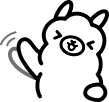

In [10]:
display.Image(file_llama)

In [11]:
%%time

response = chain.invoke(
    {
        "level_of_detail": "Be as precise as possible.",
        "image_url": image_to_base64(file_stop_sign),
    }
)

print(response.content)

This is a flat, vector-style illustration set against a stark white background. The central focus is a standard red octagonal stop sign. It features a bright red fill with a thin white border and the word "STOP" centered in bold, white, uppercase sans-serif letters.

The sign is mounted on a simple, brown, cylindrical wooden pole. Gripping the bottom of the pole is a light-skinned hand. The hand is shown from the side, with the thumb visible on the left and the fingers wrapped around the right side of the stick, indicating a firm grip. The wrist extends slightly to the right, and the illustration has no complex shading or textures, maintaining a clean, graphic look.
CPU times: user 4.01 ms, sys: 1 ms, total: 5.02 ms
Wall time: 14 s


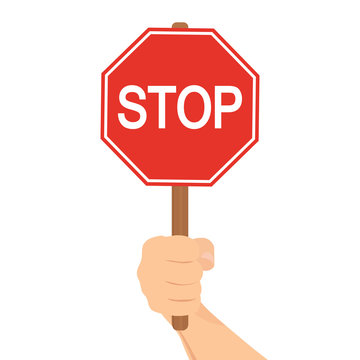

In [12]:
display.Image(file_stop_sign)

Let's assume we need to build a system that processes invoice and that we need to store specific properties of these invoices for later processing (e.g. the invoice number, due date, currency and the total amount of the invoice). 

As we saw above, we can question an LLM to analyse an image and possibly extract specific features from this image. However, when we do it as shown above, we get free text which makes further processing rather difficult. 

Let's see if we can instruct the LLM to produce structured output (e.g. JSON) we can use for further processing (allowing us to interface with other components of our software stack).

The code below showcases how structured JSON output can be requested from an LLM...

In [13]:
llm = ChatOpenAI(
    model = MODEL_MULTIMODAL,
    api_key = "ollama",
    base_url = OPENAI_BASE_URL,
    temperature = 0,
    model_kwargs = { 
        "response_format": { "type": "json_object" }
    },
)

prompt = ChatPromptTemplate(
    [
        {
            "role": "system",
            "content": "You are an experienced photographer! /no_think",
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "This image may or may not contain an animal. Please parse the image and identify the animal and what it is doing, if possible. Please format your response in JSON and use \"containsAnimal\", \"type\" and \"action\" as attributes."
                },
                {
                    "type": "image_url",
                    "image_url": "{image_url}",
                }
            ],
        },
    ]
)

chain = prompt | llm

In [14]:
%%time

response = chain.invoke(
    {
        "image_url": image_to_base64(file_llama),
    }
)

print(response.content)

{
  "containsAnimal": true,
  "type": "bear",
  "action": "waving"
}
CPU times: user 14.3 ms, sys: 1.04 ms, total: 15.3 ms
Wall time: 37.2 s


In [15]:
%%time

response = chain.invoke(
    {
        "image_url": image_to_base64(file_stop_sign),
    }
)

print(response.content)

{
  "containsAnimal": false,
  "type": null,
  "action": null
}
CPU times: user 5.67 ms, sys: 956 μs, total: 6.62 ms
Wall time: 40.3 s


<font color='red'>**TASK: Implement a prompt that instructs the LLM to extract the properties `number`, `due_date`,  `currency` and `total_amount` from the provided invoices.**</font>

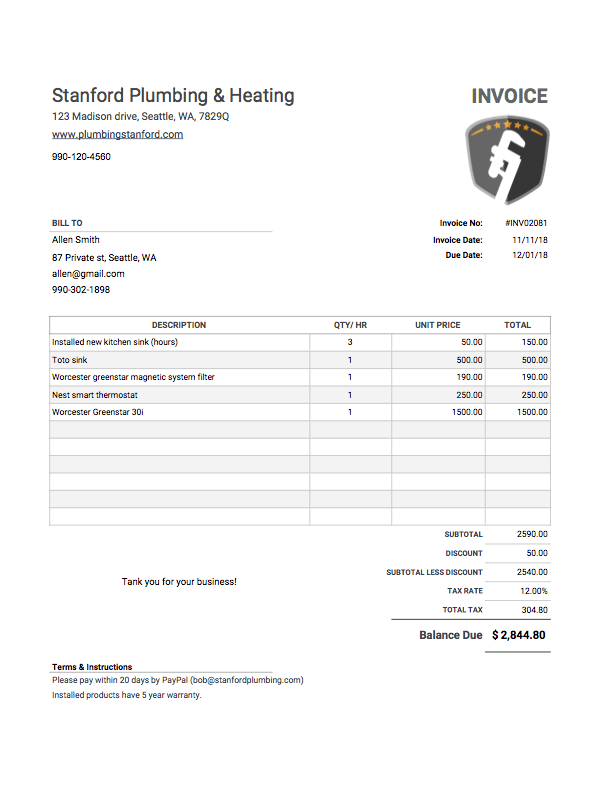

In [16]:
display.Image(file_invoice_01)

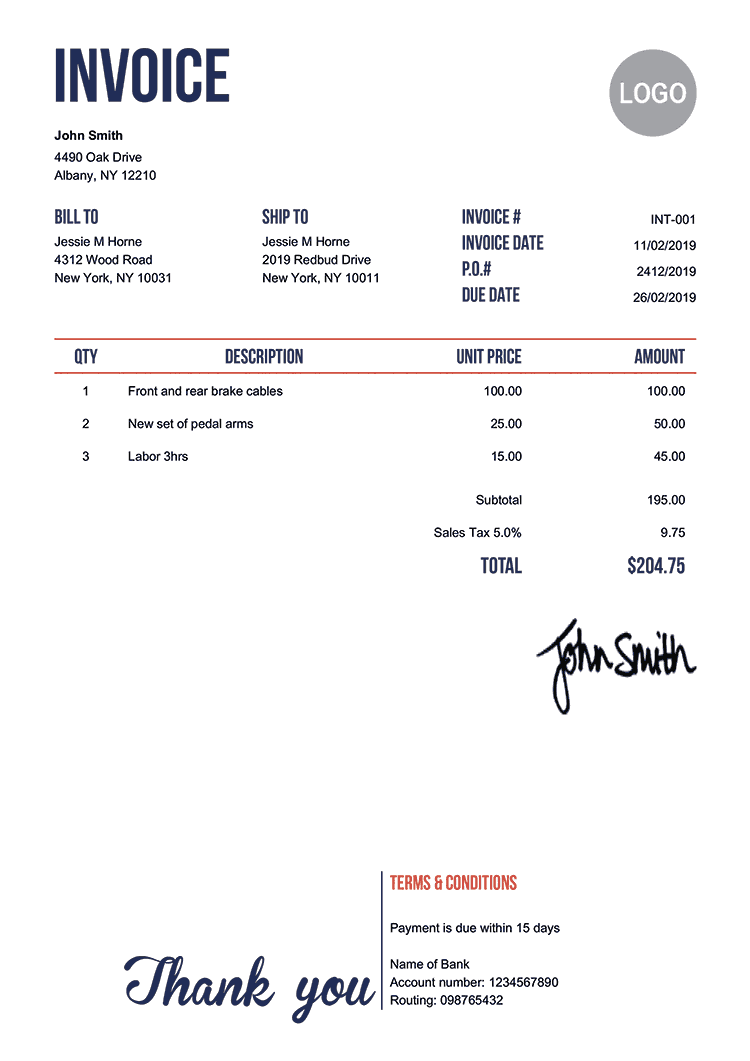

In [17]:
display.Image(file_invoice_02)

In [18]:
llm = ChatOpenAI(...)


prompt = ChatPromptTemplate(...)


chain = prompt | llm

In [19]:
%%time

response = chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_01),
    }
)

print(response.content)

{
  "invoice_number": "#INV02081",
  "due_date": "12/01/18",
  "currency": "$",
  "total_amount": "2844.80"
}
CPU times: user 6.78 ms, sys: 1.98 ms, total: 8.76 ms
Wall time: 8.63 s


In [20]:
%%time

response = chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_02),
    }
)

print(response.content)

{
  "invoice_number": "INT-001",
  "due_date": "26/02/2019",
  "currency": "$",
  "total_amount": "204.75"
}
CPU times: user 7.2 ms, sys: 137 μs, total: 7.33 ms
Wall time: 26.6 s


Alternatively, you can specify a JSON schema and use LangChain's feature to extract structured output.

<font color='red'>**TASK: Specify a JSON schema that defines the invoice and its properties you want to extract and use [LangChain's feature](https://python.langchain.com/docs/how_to/structured_output/#typeddict-or-json-schema) to extract structured output (see also [here](https://reference.langchain.com/python/langchain-openai/chat_models/base/BaseChatOpenAI/with_structured_output)).**</font>

In [21]:
json_schema = {
    ...
}


structured_llm = ...


structured_chain = prompt | structured_llm

In [22]:
%%time

response = structured_chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_01),
    }
)

print(response)

{'invoice_number': '#INV02081', 'total_amount': '2844.80', 'currency': '$'}
CPU times: user 7.28 ms, sys: 168 μs, total: 7.45 ms
Wall time: 8.36 s


In [23]:
%%time

response = structured_chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_02),
    }
)

print(response)

{'invoice_number': 'INT-001', 'total_amount': '204.75', 'currency': '$'}
CPU times: user 7.8 ms, sys: 839 μs, total: 8.64 ms
Wall time: 26.4 s


There seem to be issues with the due date...

It is also possible to specify a Pydantic class and instruct the LLM to extract its values. The key advantage of using Pydantic is that the generated output will be validated. Pydantic will raise an error if any required fields are missing or if any fields are of the wrong type.

<font color='red'>**TASK: Specify a Pydantic class that defines the invoice and its properties you want to extract and use [LangChain's feature](https://python.langchain.com/docs/how_to/structured_output/#pydantic-class) to extract structured output (see also [here](https://reference.langchain.com/python/langchain-core/language_models/chat_models/BaseChatModel/with_structured_output)).**</font>

In [24]:
from typing import Optional

from pydantic import BaseModel, Field
from datetime import date

# Pydantic
# The name of the Pydantic class, the docstring, and the names and provided descriptions of parameters are very important.
# You can effectively think of all of this information as being added to the model prompt.

class Invoice(BaseModel):
...


structured_llm = ...


structured_chain = prompt | structured_llm

In [25]:
%%time

response = structured_chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_01),
    }
)

print(response)

invoice_number='#INV02081' due_date='12/01/18' currency='$' total_amount='2844.80'
CPU times: user 8.69 ms, sys: 848 μs, total: 9.54 ms
Wall time: 8.6 s


In [26]:
%%time

response = structured_chain.invoke(
    {
        "image_url": image_to_base64(file_invoice_02),
    }
)

print(response)

invoice_number='INT-001' due_date='26/02/2019' currency='$' total_amount='204.75'
CPU times: user 10.9 ms, sys: 126 μs, total: 11 ms
Wall time: 26.8 s


Pydantic allows for [field validation](https://docs.pydantic.dev/latest/concepts/validators/#field-validators) which can be used for post processing extracted values (e.g. convert a string into a date, convert the total amount into a number etc.). 